In [1]:
# ==============================================================================
# 1.1. Импорт библиотек и загрузка данных
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Устанавливаем стиль для графиков для лучшей читаемости
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 7)

print("Библиотеки успешно импортированы.")

# --- Загрузка данных ---
# [Важно!] Убедитесь, что путь к файлу указан верно относительно вашего ноутбука.
# Судя по структуре репозитория, он должен быть примерно таким:
file_path = '../data/raw/frames_errors.csv' 

try:
    df = pd.read_csv(file_path)
    print(f"Датасет успешно загружен. Путь: '{file_path}'")
    
    # ==============================================================================
    # 1.2. Общая информация и первые строки
    # ==============================================================================
    print("\n--- Общая информация о датасете ---")
    print(f"Размер датасета (строки, колонки): {df.shape}")
    
    print("\n--- Первые 5 строк данных ---")
    display(df.head())
    
    print("\n--- Техническая информация по колонкам (типы данных, пропуски) ---")
    df.info()

except FileNotFoundError:
    print(f"Ошибка: Файл не найден по пути '{file_path}'.")
    print("Пожалуйста, проверьте путь к файлу и перезапустите ячейку.")
    df = None # Создаем пустую переменную, чтобы следующие ячейки не вызывали ошибок

Библиотеки успешно импортированы.
Датасет успешно загружен. Путь: '../data/raw/frames_errors.csv'

--- Общая информация о датасете ---
Размер датасета (строки, колонки): (328617, 51)

--- Первые 5 строк данных ---


,block_id,frame_idx,E_mu_Z,E_mu_phys_est,E_mu_X,E_nu1_X,E_nu2_X,E_nu1_Z,E_nu2_Z,N_mu_X,...,biasVoltage_2,synErr,N_EC_rounds,maintenance_flag,estimator_name,f_EC,E_mu_Z_est,R,s,p
0,989611274,0,0.10787,0.02315,0.00000,0.00000,0.00000,0.00000,0.00000,5540263.0,...,0.0,0,1,EMA,NaN,0.03297,0.75,3339,1461,NaN
1,989611274,1,0.10713,0.02427,0.04072,0.11111,0.50000,0.04723,0.40260,5539181.0,...,0.0,44,1,EMA,2.508240,0.05794,0.65,3584,1216,NaN
2,989611274,2,0.10676,0.03548,0.03742,0.00000,0.66667,0.05041,0.36842,5446219.0,...,0.0,20,1,EMA,1.783390,0.07434,0.60,3946,854,NaN
3,989611274,3,0.10820,0.04542,0.02697,0.10526,0.66667,0.06257,0.45570,5441014.0,...,0.0,12,1,EMA,1.525742,0.08515,0.55,3539,1261,NaN
4,989611274,4,0.11996,0.03889,0.03983,0.15385,1.00000,0.06999,0.40541,5445731.0,...,0.0,11,1,EMA,1.512491,0.09283,0.50,2746,2054,NaN



--- Техническая информация по колонкам (типы данных, пропуски) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 328617 entries, 0 to 328616
Data columns (total 51 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   block_id              328617 non-null  int64  
 1   frame_idx             328617 non-null  int64  
 2   E_mu_Z                328617 non-null  float64
 3   E_mu_phys_est         328169 non-null  float64
 4   E_mu_X                328617 non-null  float64
 5   E_nu1_X               328617 non-null  float64
 6   E_nu2_X               328617 non-null  float64
 7   E_nu1_Z               328617 non-null  float64
 8   E_nu2_Z               328617 non-null  float64
 9   N_mu_X                328617 non-null  float64
 10  M_mu_XX               328617 non-null  float64
 11  M_mu_XZ               328617 non-null  float64
 12  M_mu_X                328617 non-null  float64
 13  N_mu_Z                328617 non-nul

In [2]:
# ==============================================================================
# 1.3. Анализ идентификаторов и категорий
# ==============================================================================
if df is not None:
    print("\n--- Анализ ключевых идентификаторов и категорий ---")
    
    # Количество уникальных сессий/блоков
    num_unique_blocks = df['block_id'].nunique()
    print(f"Количество уникальных сессий (block_id): {num_unique_blocks}")
    
    # Распределение по типам estimator_name
    print("\nРаспределение по 'estimator_name':")
    print(df['estimator_name'].value_counts())
else:
    print("Датафрейм не загружен. Пропустите выполнение этой ячейки.")


--- Анализ ключевых идентификаторов и категорий ---
Количество уникальных сессий (block_id): 823

Распределение по 'estimator_name':
estimator_name
1.149799    1171
1.149978    1147
1.149937    1077
1.149784    1062
1.149913     994
            ... 
1.518573       1
1.583717       1
1.603759       1
1.333099       1
1.785106       1
Name: count, Length: 26792, dtype: int64



--- Анализ пропущенных значений ---
Пропуски по колонкам:


,Количество пропусков,"Процент пропусков, %"
p,328617,100.000000
E_mu_phys_est,448,0.136329
estimator_name,131,0.039864


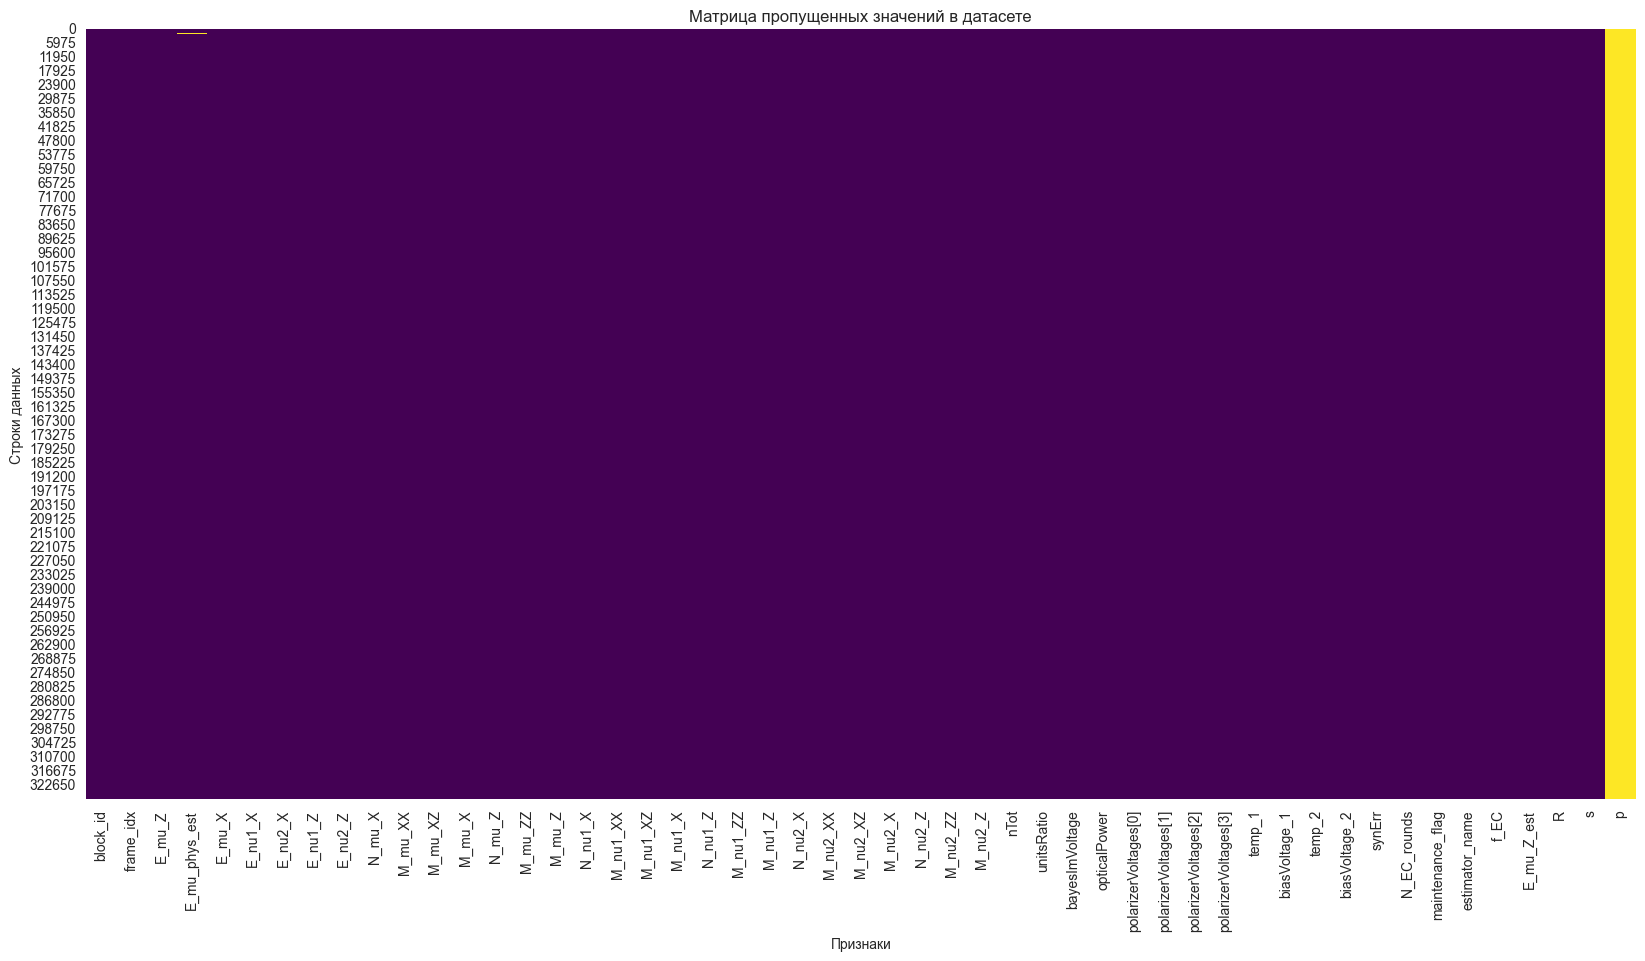

In [3]:
# ==============================================================================
# 1.4. Детальный анализ пропущенных значений
# ==============================================================================
if df is not None:
    print("\n--- Анализ пропущенных значений ---")
    
    # Считаем пропуски в каждой колонке
    missing_values = df.isnull().sum()
    missing_percentage = (missing_values / len(df)) * 100
    
    # Создаем DataFrame для удобного отображения
    missing_df = pd.DataFrame({
        'Количество пропусков': missing_values,
        'Процент пропусков, %': missing_percentage
    })
    
    # Отображаем только те колонки, где есть пропуски, сортируя по убыванию
    print("Пропуски по колонкам:")
    display(missing_df[missing_df['Количество пропусков'] > 0].sort_values(by='Количество пропусков', ascending=False))

    # Визуализация матрицы пропусков
    plt.figure(figsize=(20, 10))
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
    plt.title('Матрица пропущенных значений в датасете')
    plt.xlabel('Признаки')
    plt.ylabel('Строки данных')
    plt.show()
else:
    print("Датафрейм не загружен. Пропустите выполнение этой ячейки.")

Анализируем 328617 непропущенных значений 'E_mu_Z'.


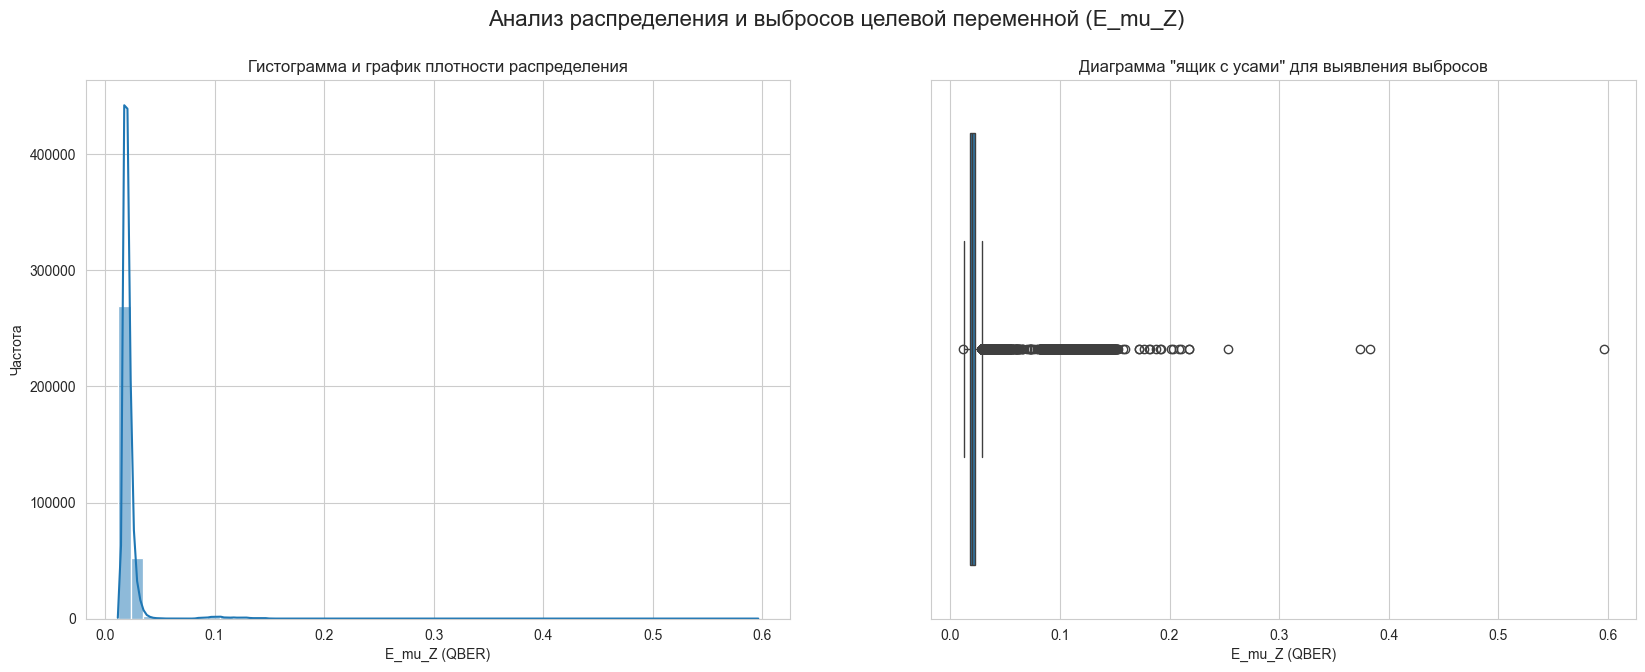

In [4]:
# ==============================================================================
# 2.1. Анализ распределения E_mu_Z
# ==============================================================================
if df is not None:
    # Проверяем, есть ли пропуски в целевой переменной, и если да, работаем с данными без них
    target_series = df['E_mu_Z'].dropna()
    print(f"Анализируем {len(target_series)} непропущенных значений 'E_mu_Z'.")

    # Создаем фигуру с двумя подграфиками
    fig, axes = plt.subplots(1, 2, figsize=(20, 7))
    fig.suptitle('Анализ распределения и выбросов целевой переменной (E_mu_Z)', fontsize=16)

    # Гистограмма и KDE-график
    sns.histplot(target_series, kde=True, ax=axes[0], bins=50)
    axes[0].set_title('Гистограмма и график плотности распределения')
    axes[0].set_xlabel('E_mu_Z (QBER)')
    axes[0].set_ylabel('Частота')

    # Boxplot для оценки выбросов
    sns.boxplot(x=target_series, ax=axes[1])
    axes[1].set_title('Диаграмма "ящик с усами" для выявления выбросов')
    axes[1].set_xlabel('E_mu_Z (QBER)')

    plt.show()
else:
    print("Датафрейм не загружен. Пропустите выполнение этой ячейки.")

In [5]:
# ==============================================================================
# 2.2. Расчет описательных статистик
# ==============================================================================
if df is not None:
    print("--- Описательные статистики для E_mu_Z ---")
    # Используем to_frame() для более красивого вывода в Jupyter
    display(target_series.describe().to_frame())
else:
    print("Датафрейм не загружен. Пропустите выполнение этой ячейки.")

--- Описательные статистики для E_mu_Z ---


,E_mu_Z
count,328617.000000
mean,0.021936
std,0.011728
min,0.011730
25%,0.018120
50%,0.019930
75%,0.022320
max,0.596320


Найдены следующие колонки с показателями ошибок: 
['E_mu_Z', 'E_mu_phys_est', 'E_mu_X', 'E_nu1_X', 'E_nu2_X', 'E_nu1_Z', 'E_nu2_Z', 'E_mu_Z_est']



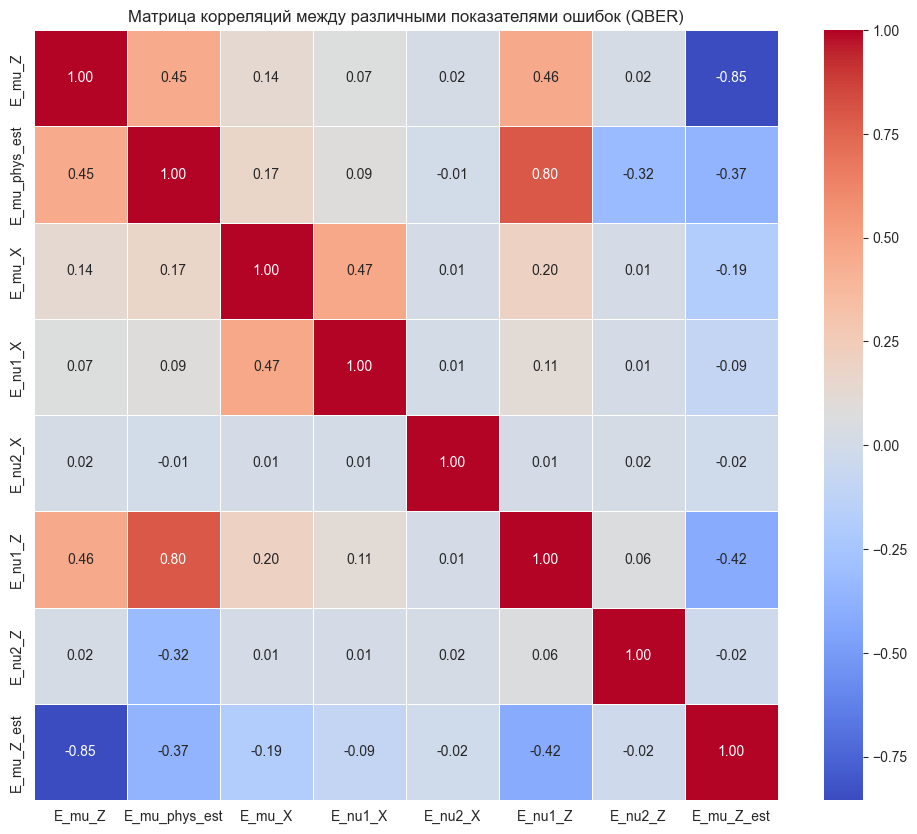

In [6]:
# ==============================================================================
# 2.3. Корреляция между различными типами ошибок (QBER)
# ==============================================================================
if df is not None:
    # Находим все колонки, связанные с ошибками (содержат 'E_')
    error_cols = [col for col in df.columns if 'E_' in col]
    print(f"Найдены следующие колонки с показателями ошибок: \n{error_cols}\n")
    
    # Рассчитываем матрицу корреляций
    correlation_matrix = df[error_cols].corr()
    
    # Визуализируем матрицу
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Матрица корреляций между различными показателями ошибок (QBER)')
    plt.show()
else:
    print("Датафрейм не загружен. Пропустите выполнение этой ячейки.")

--- Расчет корреляции всех числовых признаков с E_mu_Z ---


C:\Users\iboro\AppData\Local\Temp\ipykernel_24596\1272472005.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_correlations.values, y=top_correlations.index, palette='vlag')


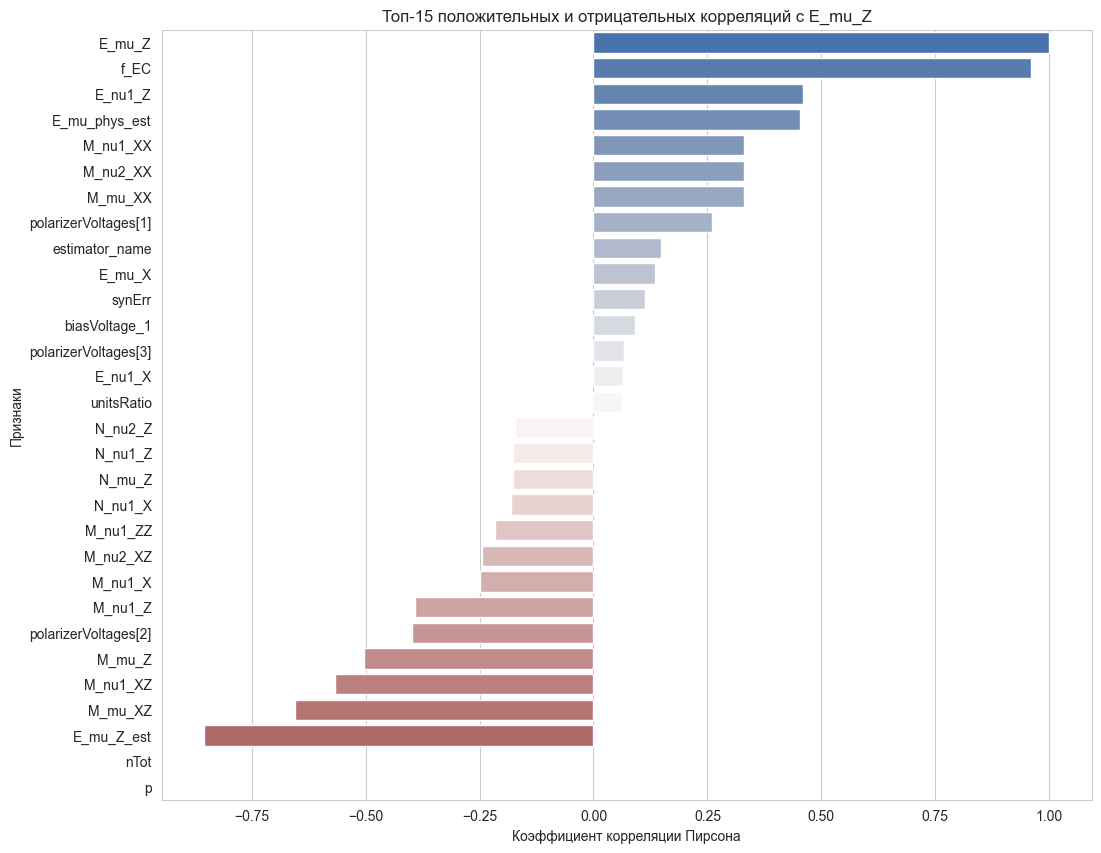


Топ-5 наиболее скоррелированных не-ошибочных признаков:
['f_EC', 'M_nu1_XX', 'M_nu2_XX', 'M_mu_XX', 'polarizerVoltages[1]']


In [7]:
# ==============================================================================
# 3.1. Корреляция числовых признаков с целевой переменной E_mu_Z
# ==============================================================================
if df is not None:
    print("--- Расчет корреляции всех числовых признаков с E_mu_Z ---")
    
    # Выбираем только числовые колонки для расчета корреляции
    numeric_df = df.select_dtypes(include=np.number)
    
    # Рассчитываем корреляцию всех признаков с нашей целевой переменной
    correlations_with_target = numeric_df.corr()['E_mu_Z'].sort_values(ascending=False)
    
    # Визуализируем наиболее сильно скоррелированные признаки
    plt.figure(figsize=(12, 10))
    # Берем топ-15 и последние 15 признаков для наглядности
    top_correlations = pd.concat([correlations_with_target.head(15), correlations_with_target.tail(15)])
    
    sns.barplot(x=top_correlations.values, y=top_correlations.index, palette='vlag')
    plt.title('Топ-15 положительных и отрицательных корреляций с E_mu_Z')
    plt.xlabel('Коэффициент корреляции Пирсона')
    plt.ylabel('Признаки')
    plt.show()

    # Сохраним названия топ-5 признаков (исключая саму себя и другие 'E_' признаки)
    # для следующего шага
    top_predictors = correlations_with_target.drop(
        labels=[col for col in correlations_with_target.index if 'E_' in col]
    ).head(5).index.tolist()
    
    print("\nТоп-5 наиболее скоррелированных не-ошибочных признаков:")
    print(top_predictors)

else:
    print("Датафрейм не загружен. Пропустите выполнение этой ячейки.")


--- Анализ характера связи для топ-5 предикторов ---


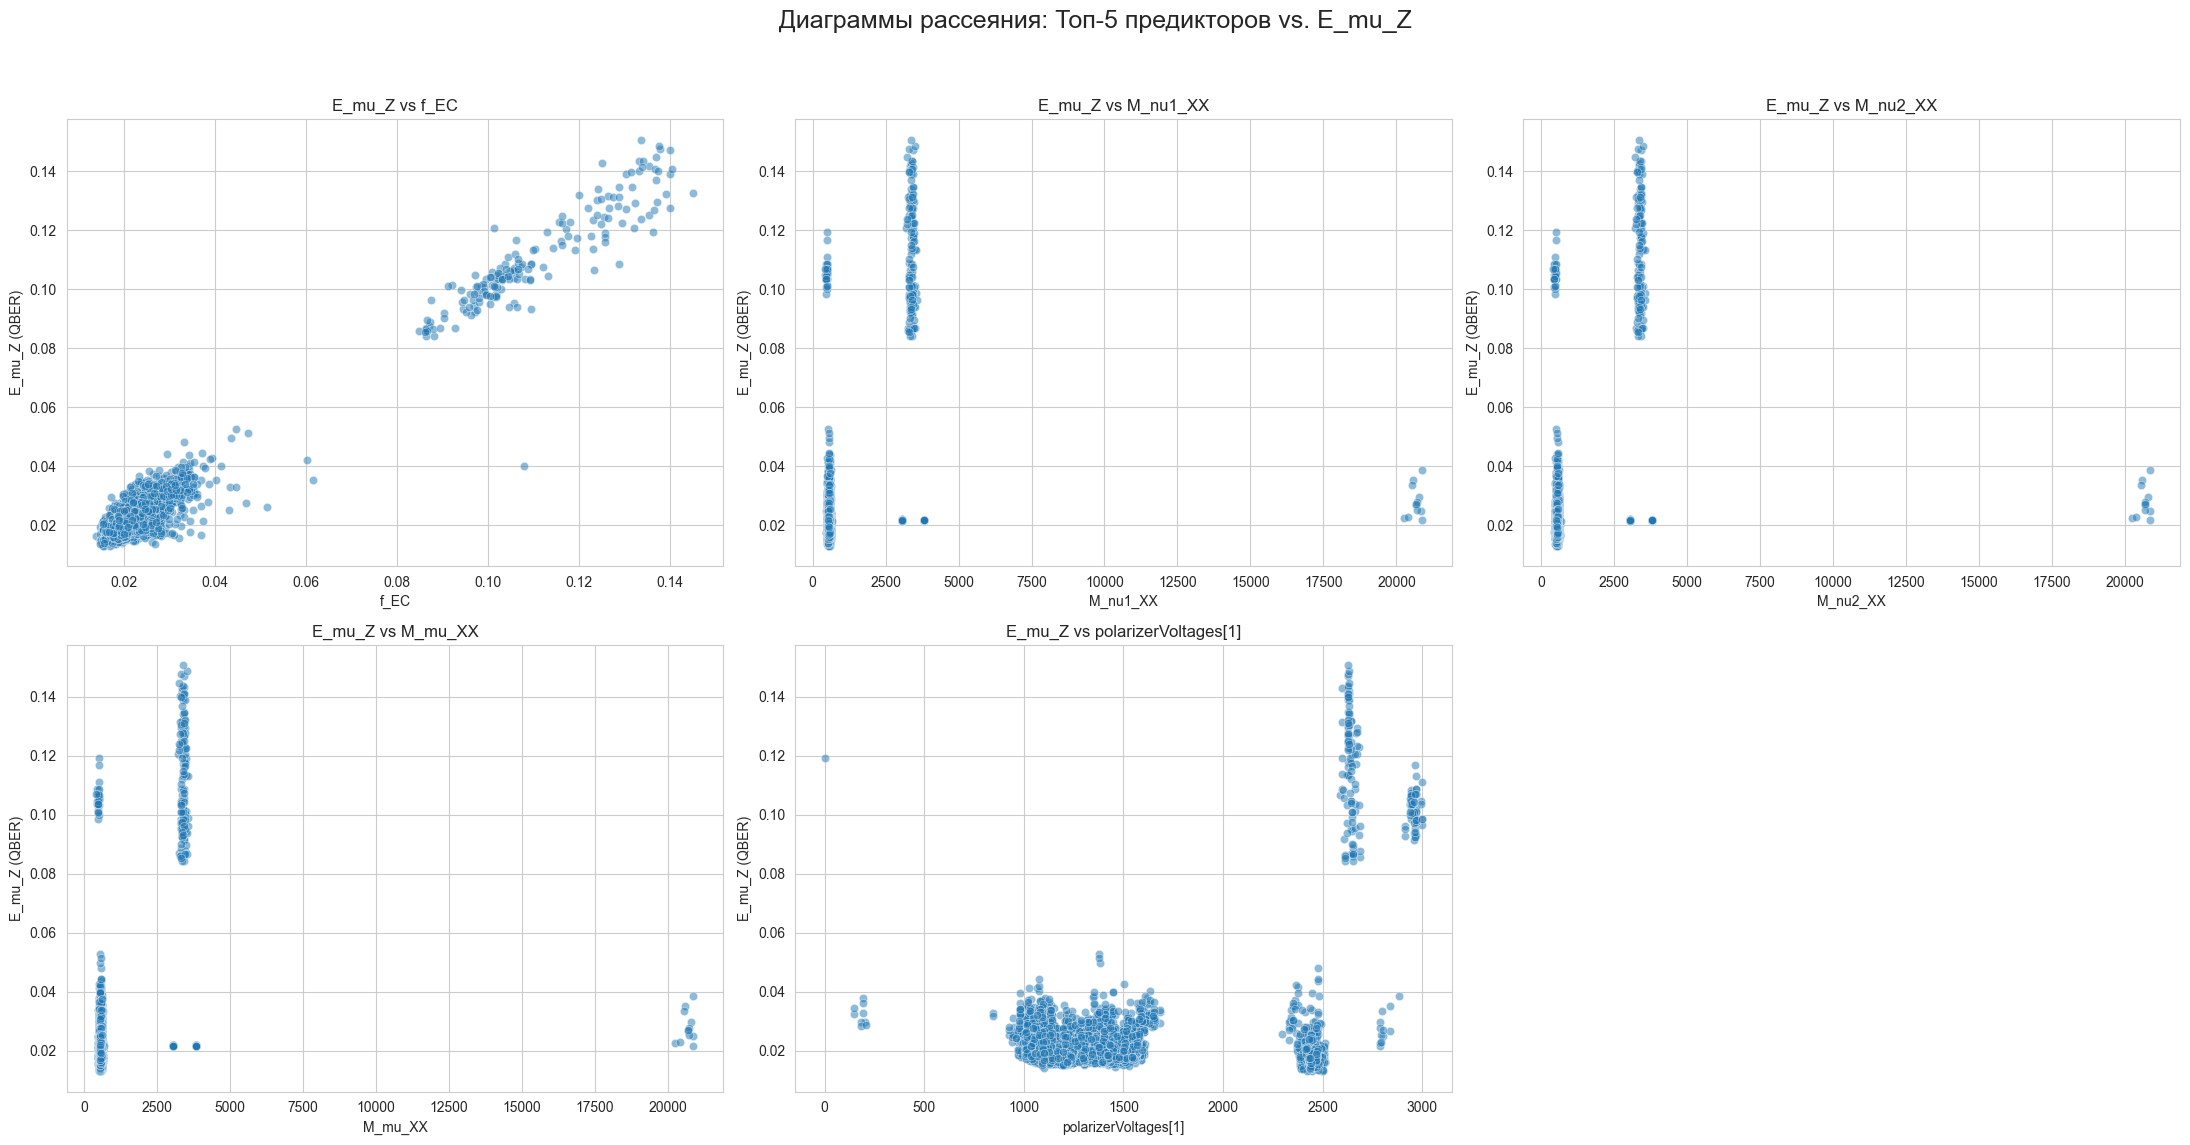

In [8]:
# ==============================================================================
# 3.2. Визуальный анализ зависимостей (Scatter Plots)
# ==============================================================================
if df is not None and 'top_predictors' in locals():
    print(f"\n--- Анализ характера связи для топ-5 предикторов ---")
    
    # Чтобы избежать долгой отрисовки и наложения точек, используем случайную выборку
    df_sample = df.sample(n=min(10000, len(df)), random_state=42)

    # Создаем сетку графиков
    fig, axes = plt.subplots(2, 3, figsize=(22, 12))
    fig.suptitle('Диаграммы рассеяния: Топ-5 предикторов vs. E_mu_Z', fontsize=18)
    
    # `axes.flatten()` позволяет удобно итерироваться по сетке графиков
    axes_flat = axes.flatten()
    
    for i, col in enumerate(top_predictors):
        sns.scatterplot(data=df_sample, x=col, y='E_mu_Z', ax=axes_flat[i], alpha=0.5)
        axes_flat[i].set_title(f'E_mu_Z vs {col}')
        axes_flat[i].set_xlabel(col)
        axes_flat[i].set_ylabel('E_mu_Z (QBER)')
    
    # Скрываем лишний пустой график, если он есть
    if len(top_predictors) < len(axes_flat):
        for i in range(len(top_predictors), len(axes_flat)):
            fig.delaxes(axes_flat[i])
            
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

else:
    print("Датафрейм не загружен или переменная top_predictors не создана.")

--- Анализ временной динамики внутри нескольких случайных сессий ---
Выбраны случайные block_id для анализа: [ 510215393 1140835128 1212227346 1757608511]


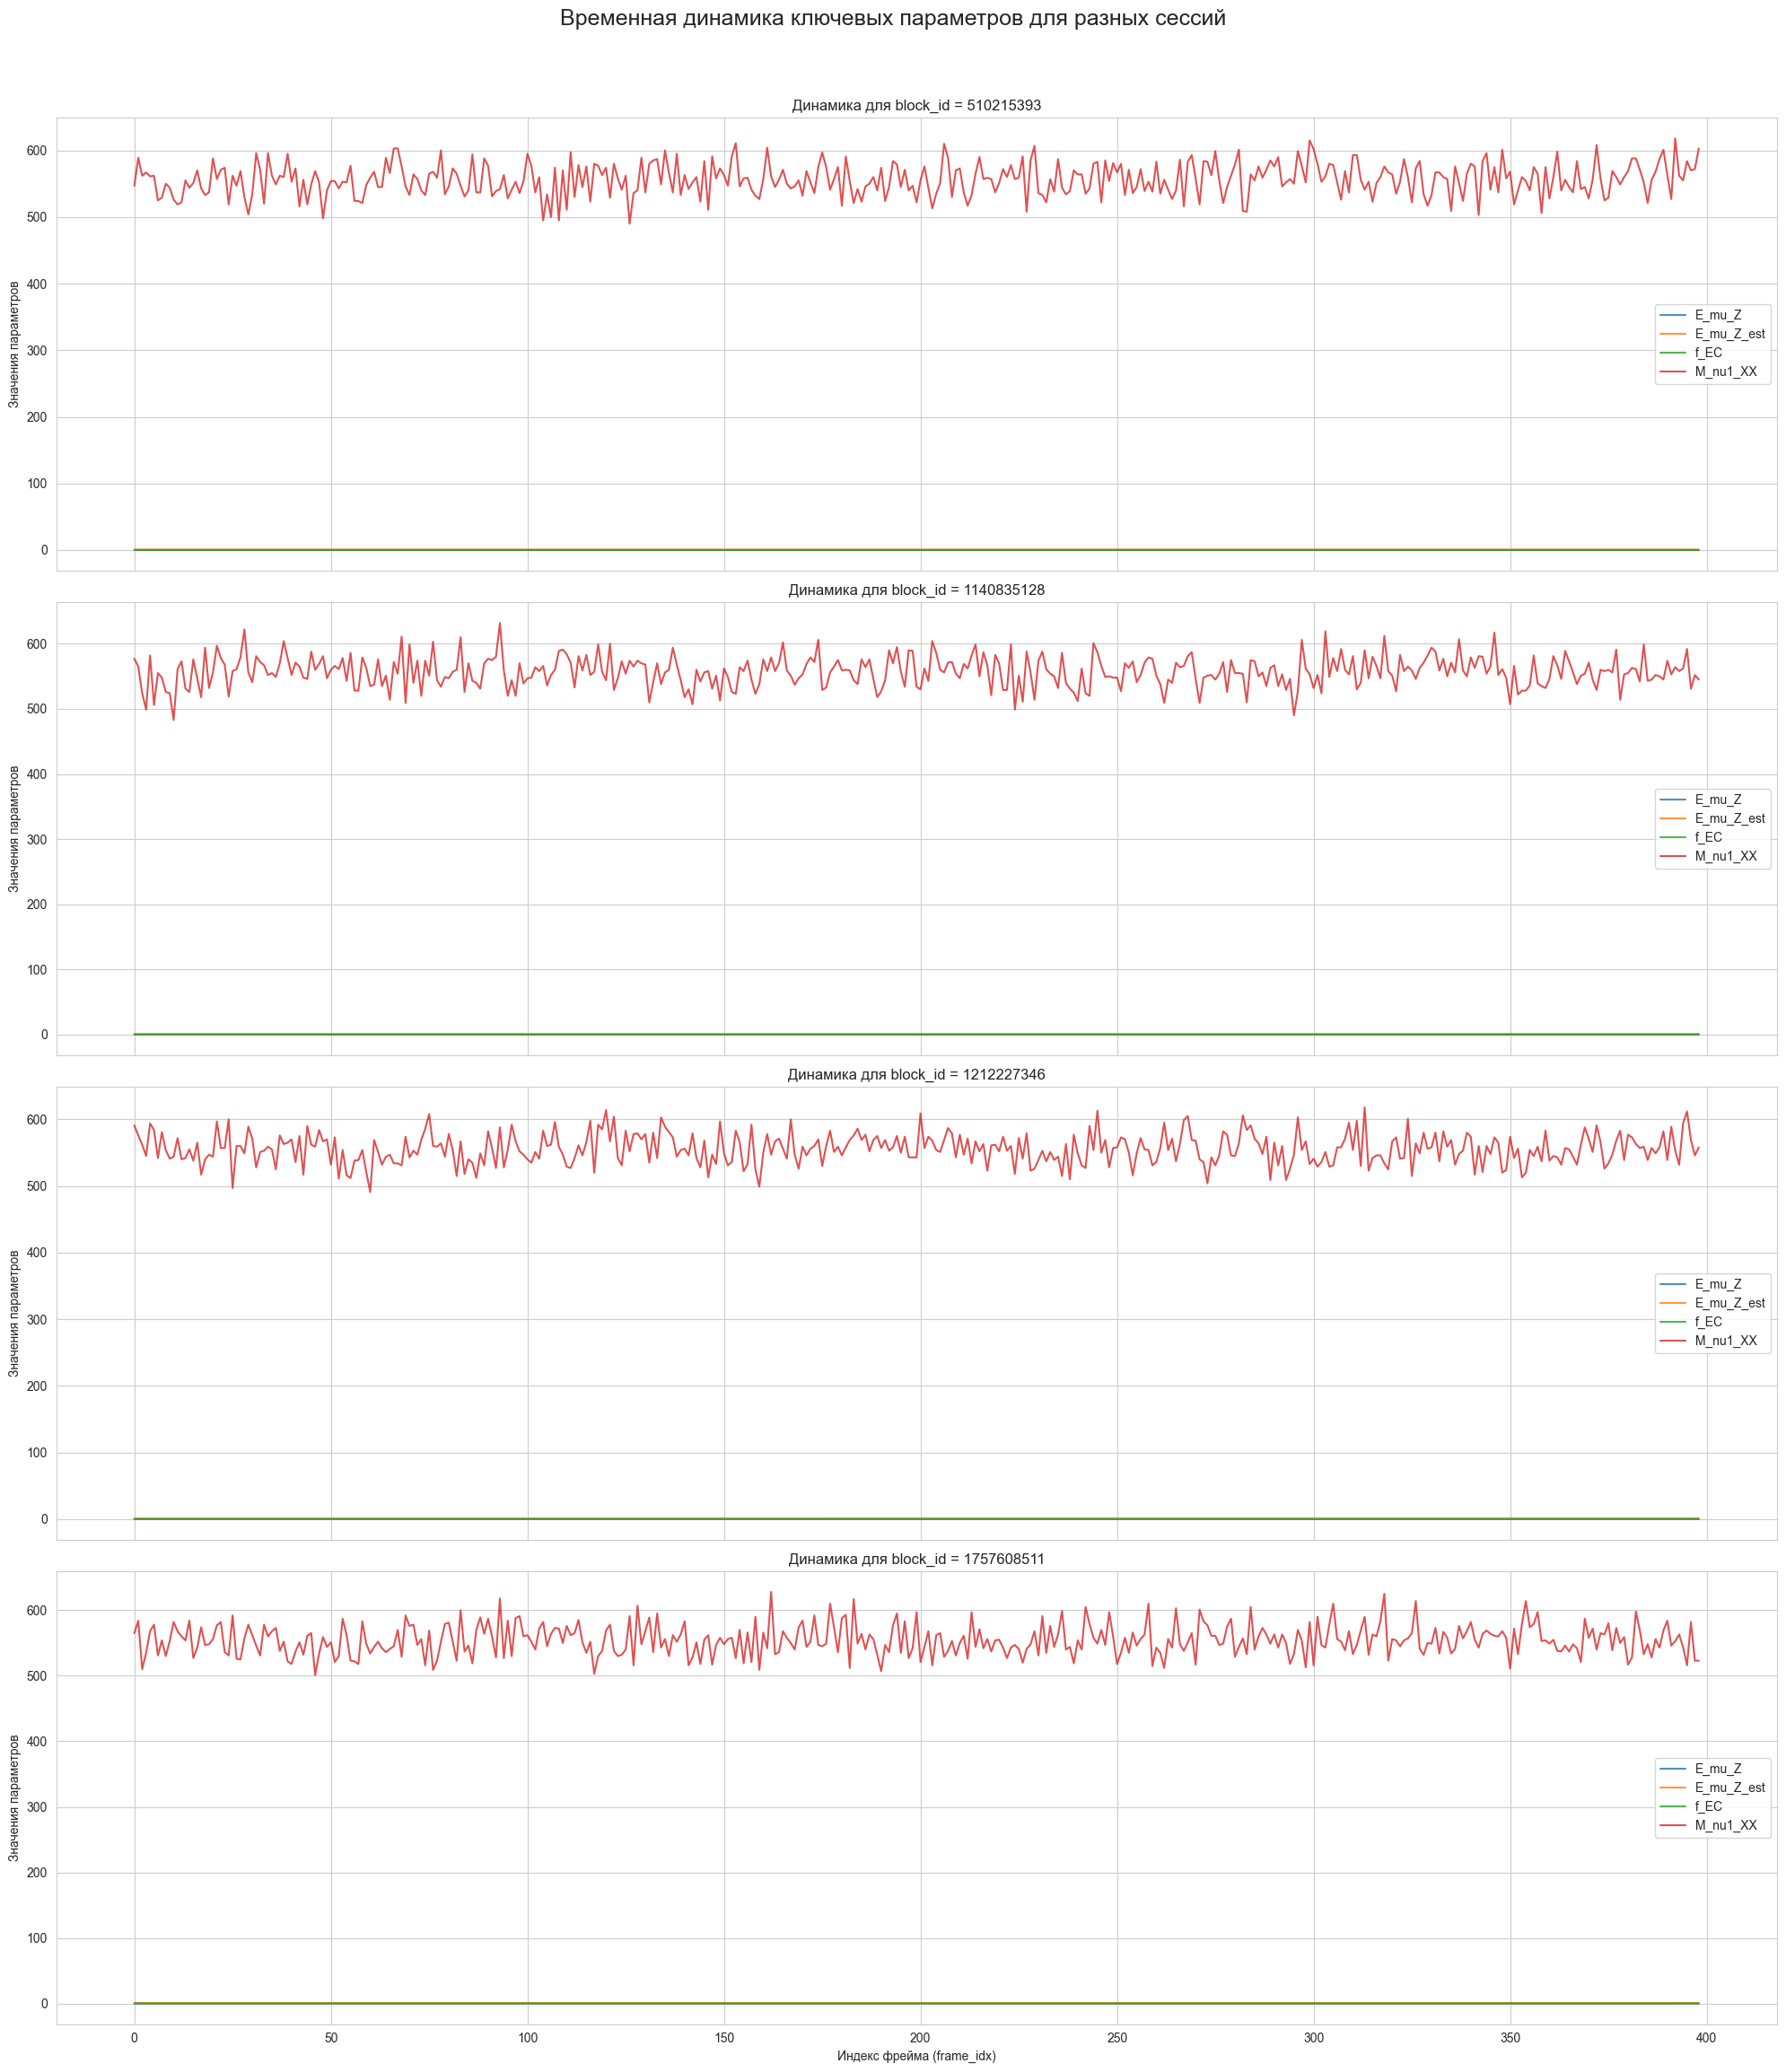

In [12]:
# ==============================================================================
# 4.1. Анализ динамики внутри сессий (block_id)
# ==============================================================================
print("--- Анализ временной динамики внутри нескольких случайных сессий ---")
    
# Получаем список уникальных block_id
all_block_ids = df['block_id'].unique()
    
# Выбираем 4 случайных ID для анализа, чтобы увидеть разнообразие
# np.random.choice обеспечивает, что мы не выйдем за пределы, если блоков мало
sample_ids = np.random.choice(all_block_ids, size=min(4, len(all_block_ids)), replace=False)
    
print(f"Выбраны случайные block_id для анализа: {sample_ids}")
    
# Признаки, которые мы хотим отслеживать во времени
# Наша цель, два главных предиктора и один "режимный" предиктор
features_to_plot = ['E_mu_Z', 'E_mu_Z_est', 'f_EC', 'M_nu1_XX']
    
# Создаем сетку графиков
fig, axes = plt.subplots(len(sample_ids), 1, figsize=(20, 6 * len(sample_ids)), sharex=True)
fig.suptitle('Временная динамика ключевых параметров для разных сессий', fontsize=18, y=0.99)

for i, block_id in enumerate(sample_ids):
    # Фильтруем данные для текущего block_id
    df_block = df[df['block_id'] == block_id].sort_values('frame_idx')
        
    ax = axes[i]
        
    # Строим графики для каждого признака
    for feature in features_to_plot:
        ax.plot(df_block['frame_idx'], df_block[feature], label=feature, alpha=0.8)
            
    ax.set_title(f'Динамика для block_id = {block_id}')
    ax.set_ylabel('Значения параметров')
    ax.legend()
    ax.grid(True)

axes[-1].set_xlabel('Индекс фрейма (frame_idx)')
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()


--- Сравнение распределения E_mu_Z между разными сессиями ---


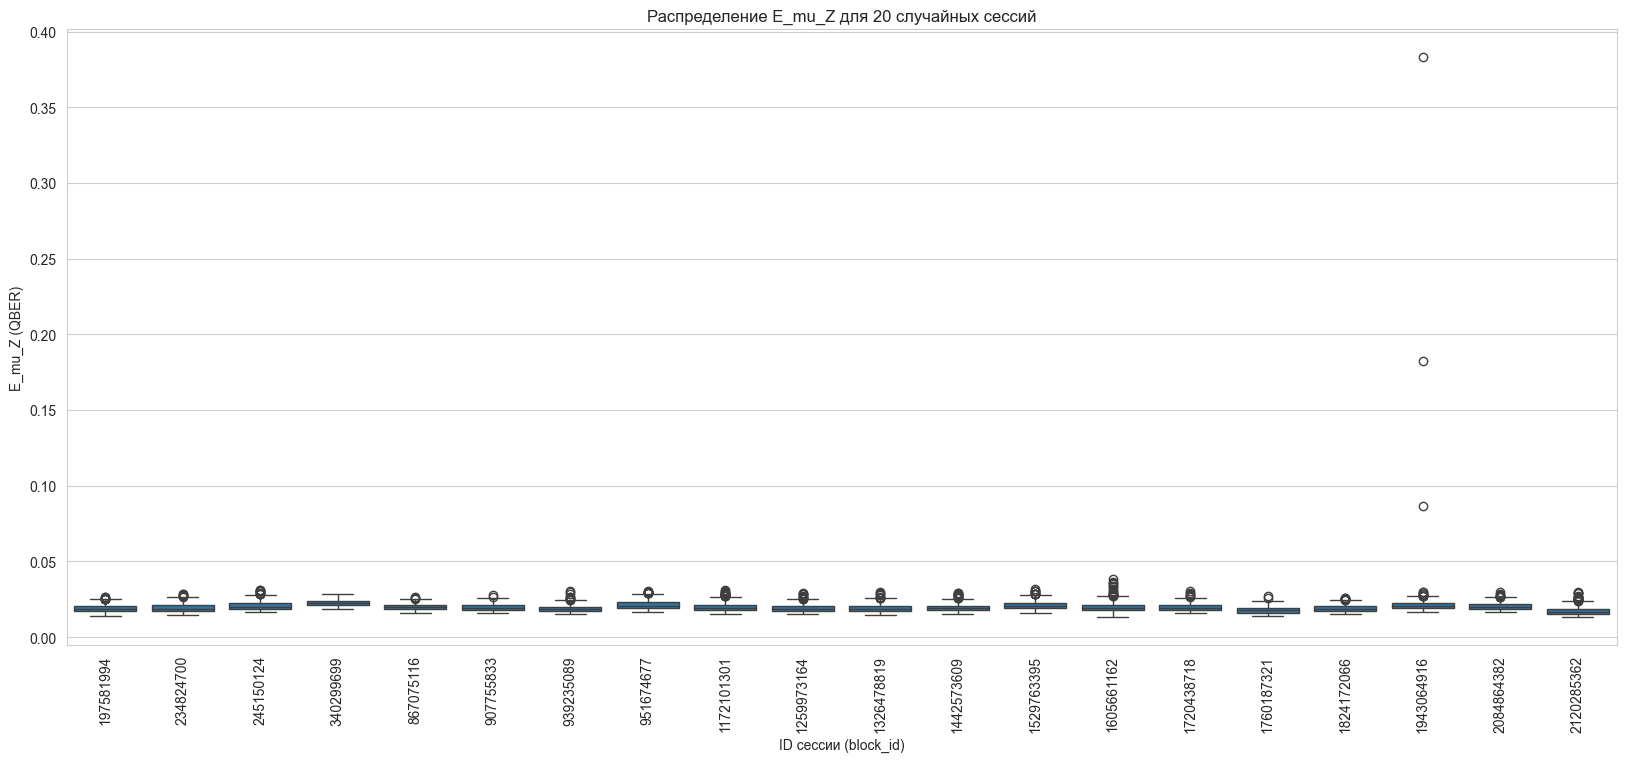

In [13]:
# ==============================================================================
# 4.2. Сравнение статистик между сессиями
# ==============================================================================
if df is not None:
    print("\n--- Сравнение распределения E_mu_Z между разными сессиями ---")
    
    # Возьмем больше случайных сессий для построения boxplot
    sample_ids_for_boxplot = np.random.choice(all_block_ids, size=min(20, len(all_block_ids)), replace=False)
    
    df_sample_blocks = df[df['block_id'].isin(sample_ids_for_boxplot)]
    
    plt.figure(figsize=(20, 8))
    sns.boxplot(data=df_sample_blocks, x='block_id', y='E_mu_Z')
    plt.title('Распределение E_mu_Z для 20 случайных сессий')
    plt.xlabel('ID сессии (block_id)')
    plt.ylabel('E_mu_Z (QBER)')
    plt.xticks(rotation=90)
    plt.show()

else:
    print("Датафрейм не загружен. Пропустите выполнение этой ячейки.")

--- Анализ выбора скорости кода (R) в зависимости от E_mu_Z ---


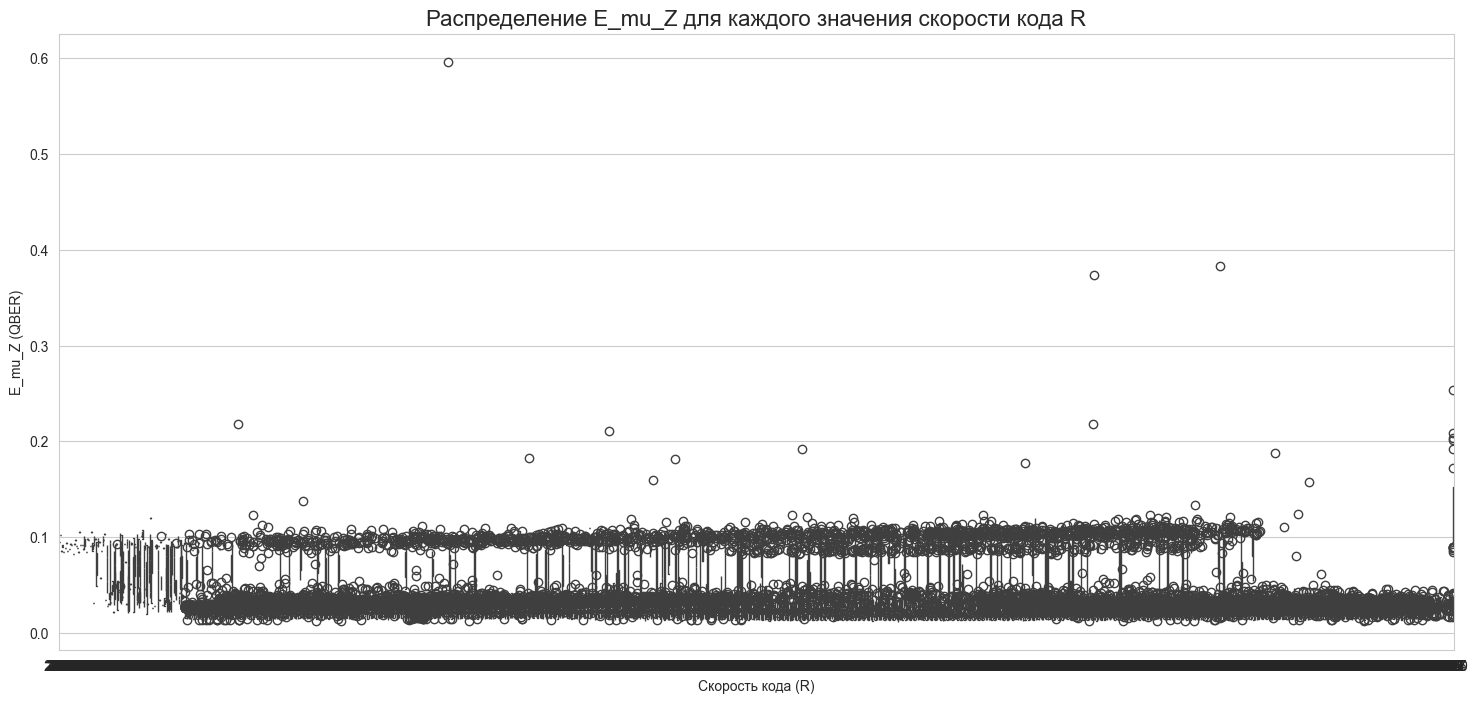

In [14]:
# ==============================================================================
# 5.1. Анализ зависимости выбора скорости кода (R) от уровня ошибок
# ==============================================================================
if df is not None:
    print("--- Анализ выбора скорости кода (R) в зависимости от E_mu_Z ---")
    
    # Сортируем значения R для более логичного отображения на графике
    sorted_r_values = sorted(df['R'].unique())
    
    plt.figure(figsize=(18, 8))
    sns.boxplot(data=df, x='R', y='E_mu_Z', order=sorted_r_values)
    plt.title('Распределение E_mu_Z для каждого значения скорости кода R', fontsize=16)
    plt.xlabel('Скорость кода (R)')
    plt.ylabel('E_mu_Z (QBER)')
    plt.show()

else:
    print("Датафрейм не загружен. Пропустите выполнение этой ячейки.")


--- Анализ выбора числа сокращенных узлов (s) в зависимости от E_mu_Z ---


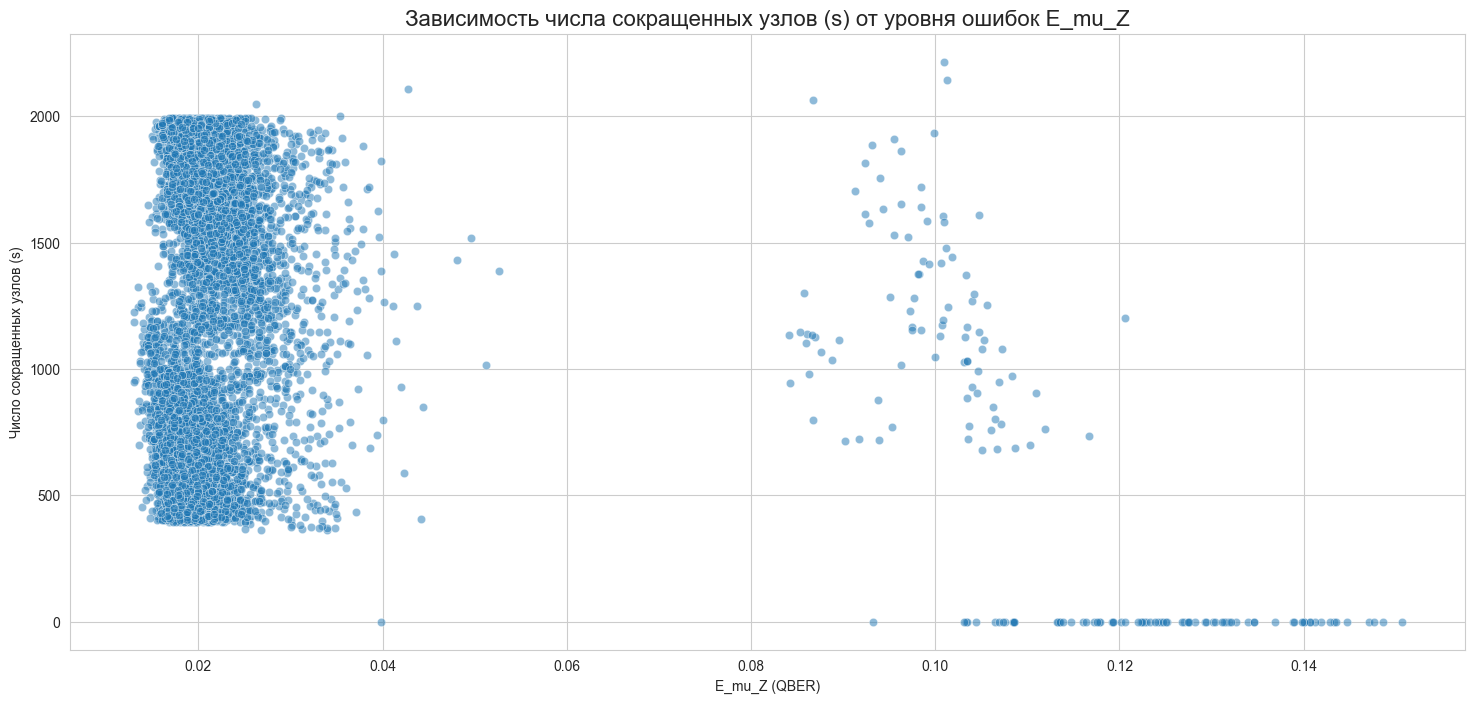

In [15]:
# ==============================================================================
# 5.2. Анализ зависимости выбора числа сокращенных узлов (s) от уровня ошибок
# ==============================================================================
if df is not None:
    print("\n--- Анализ выбора числа сокращенных узлов (s) в зависимости от E_mu_Z ---")
    
    # Используем случайную выборку для scatter plot, чтобы он был читаемым
    df_sample = df.sample(n=min(10000, len(df)), random_state=42)

    plt.figure(figsize=(18, 8))
    sns.scatterplot(data=df_sample, x='E_mu_Z', y='s', alpha=0.5)
    plt.title('Зависимость числа сокращенных узлов (s) от уровня ошибок E_mu_Z', fontsize=16)
    plt.xlabel('E_mu_Z (QBER)')
    plt.ylabel('Число сокращенных узлов (s)')
    plt.show()

else:
    print("Датафрейм не загружен. Пропустите выполнение этой ячейки.")


--- Взаимосвязь между выбором R и s ---


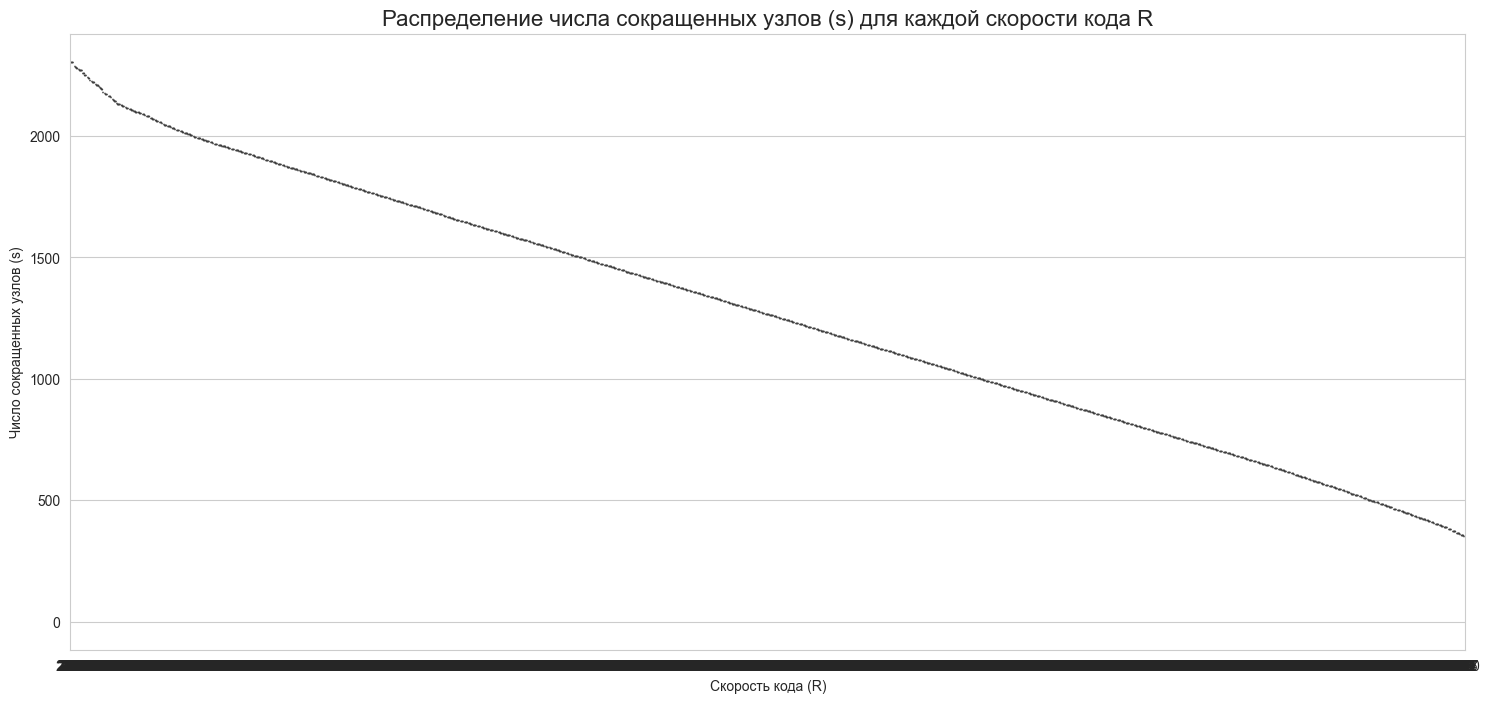

In [16]:
# ==============================================================================
# 5.3. Взаимосвязь между выбранными параметрами R и s
# ==============================================================================
if df is not None:
    print("\n--- Взаимосвязь между выбором R и s ---")

    plt.figure(figsize=(18, 8))
    sns.boxplot(data=df, x='R', y='s', order=sorted_r_values)
    plt.title('Распределение числа сокращенных узлов (s) для каждой скорости кода R', fontsize=16)
    plt.xlabel('Скорость кода (R)')
    plt.ylabel('Число сокращенных узлов (s)')
    plt.show()
    
else:
    print("Датафрейм не загружен. Пропустите выполнение этой ячейки.")